<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/banner.svg"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# **Workshop: Decodificación de Gliomas con ML e IA Interpretable**
# **Proyecto Endowment I+D: DI-07-25/ICS | UNAB - PUC - FALP**
---

# **Módulo: fMRI**

# **1. Definición y Naturaleza de la fMRI**


La resonancia magnética funcional (del inglés, *Functional Magnetic Resonance Imaging*, fMRI)  se define como una técnica que utiliza el contraste intrínseco de $T2*$ para generar imágenes de activación cerebral. Su objetivo es responder preguntas sobre la topografía funcional, las conexiones cerebrales y los mecanismos neuronales subyacentes, tanto en sujetos sanos como en diversas patologías.


# **2. El Contraste BOLD: El "Transductor" Físico**

El método para cuantificar esta activación es el BOLD (*Blood Oxygenation Level Dependent*). Físicamente, este proceso se rige por la **susceptibilidad magnética** (χ) de la hemoglobina:

* **Estado Diamagnético (Oxihemoglobina ($O_2$Hb)):** Cuando la hemoglobina está saturada de $O_2$, sus propiedades magnéticas son nulas o mínimas. Esto mantiene el campo magnético local homogéneo, resultando en un $T2^*$ **largo**.

* **Estado Paramagnético (Desoxihemoglobina (dHb)):** Al perder el oxígeno, la molécula es atraída por el campo magnético del resonador. Esto genera micro-gradientes que causan una pérdida de fase más rápida en los protones, lo que **acorta** el $T2^*$.

<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/fMRI1.svg" height="500" style="width: auto;">

Propiedades magnéticas de la (a) oxihemoglobina y de la (b) desoxihemoglobina.



# **3. Ecuaciones de Decaimiento y Señal**

La señal BOLD se manifiesta físicamente como un cambio en el tiempo de relajación transversal efectivo ($T2^*$). La intensidad de la señal $S$ capturada por el resonador en un tiempo de eco ($TE$) sigue la ley de decaimiento:

$$S(TE) = S_0 \cdot e^{-\frac{TE}{T2^*}}$$

Donde:

* $S_0$: Intensidad de la señal inicial.
* $TE$: Tiempo de Eco (parámetro de la secuencia).
* $T2^*$: Tiempo de relajación transversal efectivo.


# **4. ¿Dónde reside la señal BOLD en esta ecuación?**

La señal BOLD es la variación de $S$ en función de la concentración de desoxihemoglobina (dHb). Matemáticamente, el componente "sensible" es el término $T2'$:

Matemáticamente, el $T2^*$ se compone de:

$$\frac{1}{T2^*} = \frac{1}{T2} + \frac{1}{T2'}$$

En esta relación:
* $T2$ representa el decaimiento natural por interacciones espín-espín.
* $T2'$ representa el decaimiento adicional debido a las **inhomogeneidades del campo magnético** inducidas por la presencia de moléculas paramagnéticas (desoxihemoglobina).


# **5. Dinámica de la Activación Cerebral**

Cuando una región del cerebro se activa, ocurre un proceso fisiológico conocido como **hiperemia reactiva**:

* **Aumento de Flujo:** El flujo sanguíneo aumenta significativamente hacia el área activa.

* **Lavado de dHb**: El aporte de sangre oxigenada ($O_2$Hb, que es diamagnética) supera el consumo de oxígeno local, disminuyendo la concentración de desoxihemoglobina.

* **Aumento de Señal:** Al reducirse la dHb, el valor de $T2'$ disminuye (hay menos inhomogeneidades), lo que resulta en un **aumento** de $T2^*$.

Como resultado, la diferencia de señal entre el estado de activación y el estado basal ($\Delta S$) se puede expresar como:

$$\Delta S \approx S_{activación} - S_{basal}$$


<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/fMRI2.svg" height="300" style="width: auto;">

Generación del contraste $T2^*$ en fMRI. TE significa tiempo de eco. La diferencia de señal entre el estado estimulado (activación) y el estado basal es muy pequeña.

# **6. Cuantificación de la Señal**

Lo que finalmente visualizamos como "activación" es el cambio porcentual de la señal, conocido como Contraste BOLD:

$$\% \text{ Señal BOLD} = \frac{\Delta S}{S_{basal}} \times 100$$

Este cambio es pequeño (entre 0.3% y 3%), es suficiente para ser detectado estadísticamente mediante el **Modelo General Lineal (GLM)**, donde la señal medida $y$ se descompone como:$$y = X\beta + \epsilon$$Donde $X$ representa el diseño del experimento (paradigma) multiplicado por la función de respuesta hemodinámica.

<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/fMRI3.svg" height="300" style="width: auto;">



Función de la respuesta hemodinámica ante un estímulo de corta duración.

# **Introducción y Contexto del fMRI**

En este módulo, analizaremos una imagen de un paciente con glioma. A diferencia de una imagen anatómica ($T1$), el fMRI es una serie temporal 4D que mide cambios en el flujo sanguíneo relacionados con la actividad neuronal (señal BOLD).

**El reto en Gliomas:** La presencia de un tumor altera la anatomía y puede afectar la señal hemodinámica. Nuestro objetivo es limpiar el ruido para poder ver la conectividad funcional del cerebro.


# **1. Instalación y Carga de Datos**
En esta primera etapa, preparamos nuestro entorno. Trabajaremos con la librería `nilearn`, que es el estándar de oro para el análisis de neuroimagen en Python. Cargaremos un archivo `.nii.gz` (formato NIfTI), que contiene la información funcional de un paciente con glioma. Es importante notar que el fMRI es un dato **4D:** tres dimensiones espaciales (**X, Y, Z**) y una dimensión temporal (**el tiempo**).




In [4]:
# 1. Instalación de dependencias
!pip install nilearn nibabel matplotlib ipywidgets -q

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting, image, input_data
from ipywidgets import interact, IntSlider, fixed, widgets
import os

# 2. Descarga del dataset del workshop
url = "https://github.com/pamelaFranco/workshop_glioma/raw/main/Dataset/anon_8_funcional_reposo.nii.gz"
file_name = "glioma_rsfMRI.nii.gz"

if not os.path.exists(file_name):
    !wget -O {file_name} {url}

# 3. Carga y metadatos
img = nib.load(file_name)
print(f"Dimensiones (X, Y, Z, Tiempo): {img.shape}")
print(f"TR (Tiempo de Repetición): {img.header.get_zooms()[3]} segundos")

Dimensiones (X, Y, Z, Tiempo): (128, 128, 19, 200)
TR (Tiempo de Repetición): 1.0 segundos


# **2. Exploración Visual Interactiva**

Antes de procesar, debemos inspeccionar la calidad de la imagen. Dado que el fMRI es una serie de "fotografías" tomadas a lo largo del tiempo, podemos navegar por los diferentes volúmenes. En pacientes con glioma, buscamos identificar visualmente dónde se encuentra la masa tumoral y cómo distorsiona los surcos cerebrales.

In [5]:
def explorar_fmri(volumen_index):
    # Seleccionamos un punto específico en el tiempo
    vol_img = image.index_img(img, volumen_index)

    # Visualización ortogonal (axial, sagital y coronal)
    display = plotting.plot_epi(
        vol_img,
        title=f"Exploración Temporal - Volumen: {volumen_index}",
        display_mode='ortho',
        draw_cross=True,
        cmap='gray'
    )
    plt.show()

# Widget interactivo para navegar por el tiempo
interact(explorar_fmri, volumen_index=IntSlider(min=0, max=img.shape[3]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='volumen_index', max=199), Output()), _dom_classes=('widg…

<function __main__.explorar_fmri(volumen_index)>

# **3. Pre-procesamiento - El *Smoothing***


**Suavizado Espacial (*Smoothing*)**

El suavizado aplica un filtro Gaussiano a la imagen. Se hace por tres razones principales:

* **Relación Señal-Ruido:** Reduce el ruido aleatorio de alta frecuencia.

* **Normalidad:** Ayuda a que los datos se ajusten mejor a los modelos estadísticos.

* **Anatomía:** Compensa las pequeñas variaciones anatómicas entre sujetos (o los desplazamientos causados por el tumor).

**Nota:** Un FWHM muy alto "borrará" los límites del glioma, haciéndonos perder los bordes precisos del tumor o mezclar señales de tejido sano con tejido patológico.

In [6]:
def comparar_suavizado(fwhm):
    # Aplicamos suavizado solo al primer volumen para comparar
    vol_0 = image.index_img(img, 0)
    suavizada = image.smooth_img(vol_0, fwhm=fwhm)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plotting.plot_epi(vol_0, axes=axes[0], title="Original (Sin Filtro)", display_mode='z', cut_coords=5)
    plotting.plot_epi(suavizada, axes=axes[1], title=f"Suavizada (FWHM={fwhm}mm)", display_mode='z', cut_coords=5)
    plt.show()

interact(comparar_suavizado, fwhm=IntSlider(min=0, max=12, step=2, value=4))

interactive(children=(IntSlider(value=4, description='fwhm', max=12, step=2), Output()), _dom_classes=('widget…

<function __main__.comparar_suavizado(fwhm)>

# **4. Limpieza de Señal y Filtrado Temporal**

En el estado de reposo (Resting State), nos interesan las fluctuaciones de baja frecuencia (0.01 - 0.1 Hz). La señal original tiene ruido por el latido del corazón, la respiración y el movimiento del paciente. Usaremos `clean_img` para:

* **Detrending:** Eliminar tendencias lineales (deriva del imán).

* **Band-pass filtering:** Mantener solo las frecuencias de interés.

* **Estandarización:** Convertir la señal a puntajes Z para que los vóxeles sean comparables.

In [7]:
# Aplicamos el suavizado a toda la serie 4D antes de limpiar
img_smoothed = image.smooth_img(img, fwhm=6)

# Limpieza profunda
img_cleaned = image.clean_img(
    img_smoothed,
    detrend=True,
    standardize=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

print("Procesamiento completado: Imagen limpia y filtrada lista para análisis.")

/tmp/ipykernel_999/288238829.py:5: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  img_cleaned = image.clean_img(
/tmp/ipykernel_999/288238829.py:5: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  img_cleaned = image.clean_img(


Procesamiento completado: Imagen limpia y filtrada lista para análisis.


# **5: Análisis de Conectividad (*Seed-based*)**

Finalmente, extraeremos la señal BOLD. En el contexto de este módulo, es útil comparar la "firma" del tiempo de un área afectada por el glioma vs una sana.

* **La señal BOLD:** Representa las variaciones en el oxígeno de la sangre. Si dos áreas tienen señales similares (correlacionadas), decimos que están funcionalmente conectadas.

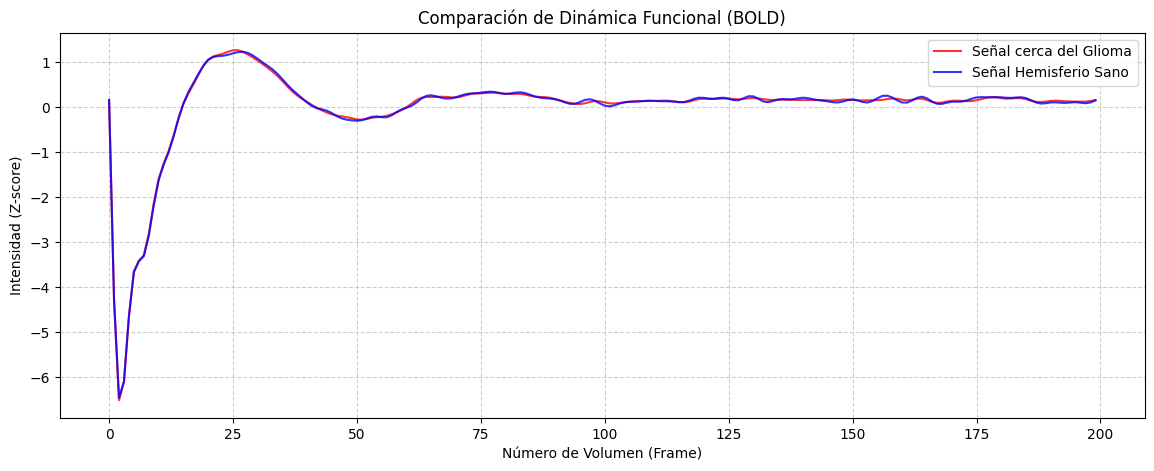

In [9]:
# Definimos dos puntos para comparar: una zona sospechosa de tumor y una sana
# Nota: Los asistentes pueden intentar cambiar estas coordenadas
coords_analisis = [
    (25, -15, 10),  # Posible ubicación Tumor
    (-25, -15, 10)  # Zona espejo sana
]

masker = input_data.NiftiSpheresMasker(coords_analisis, radius=6)
series_temporales = masker.fit_transform(img_cleaned)

# Graficar resultados
plt.figure(figsize=(14, 5))
plt.plot(series_temporales[:, 0], label="Señal cerca del Glioma", color='red', alpha=0.8)
plt.plot(series_temporales[:, 1], label="Señal Hemisferio Sano", color='blue', alpha=0.8)
plt.title("Comparación de Dinámica Funcional (BOLD)")
plt.xlabel("Número de Volumen (Frame)")
plt.ylabel("Intensidad (Z-score)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **⚠️ Nota Importante: Uso Educativo y Limitaciones Técnicas en fMRI**

Este módulo forma parte del *pipeline* práctico para comprender la Neuroimagen Funcional y la señal BOLD. Es fundamental considerar las siguientes precisiones técnicas antes de proceder:

* **Diagnóstico Médico:** Los mapas de activación o conectividad funcional generados en este *notebook* son representaciones estadísticas sujetas a umbrales. Nunca deben utilizarse para la delimitación de áreas elocuentes en planificación quirúrgica o diagnósticos clínicos sin la supervisión de un neuroradiólogo y el uso de software certificado (FDA/CE).

* **Acoplamiento Neurovascular:** La señal BOLD es una medida indirecta de la actividad neuronal. En pacientes con gliomas de alto grado, el fenómeno de acoplamiento neurovascular deteriorado puede provocar falsos negativos (ausencia de señal en zonas con actividad neuronal real) debido a la angiogénesis tumoral y la distorsión de los capilares.

* **Artefactos de Movimiento y Masa:** La presencia de una masa tumoral altera el espacio anatómico estándar (MNI). Los procesos de alineación y registro pueden presentar errores mayores en estas zonas. Asimismo, pequeñas fluctuaciones por la respiración o el latido cardíaco pueden confundirse con conectividad funcional si no se aplica un filtrado temporal riguroso.

* **Naturaleza de los Datos:** Esta imagen ha sido anonimizada y procesada con fines puramente académicos para el *workshop*. La interpretación de la conectividad en *resting state* requiere una comprensión profunda de las redes neuronales por defecto y sus alteraciones en patologías oncológicas.